In [1]:
%load_ext autoreload
%autoreload 1

In [2]:
from Bio import Entrez
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from IPython.display import display, clear_output

In [4]:
import glob
import subprocess

In [7]:
import os, pickle

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [14]:
import itertools

## Outline
Notebook containing analyses and metadata formatting for yeast genomics

In [5]:
# load Saccharomycotina db
md = pd.read_excel('./../data/md/adj4503_data_s1.xlsx', skiprows=1)

In [6]:
md['Genome_Acc']

0       JANIWC000000000
1       JAKTQS000000000
2       JAKTPX000000000
3       JANIJM000000000
4       JAJMDR000000000
             ...       
1149    GCA_001005505.1
1150    GCA_000710315.1
1151    GCF_000235365.1
1152    JAKTRD000000000
1153    GCA_000764455.1
Name: Genome_Acc, Length: 1154, dtype: object

## 1. Write list of genomes for download

In [19]:
Entrez.email = "michael.hoffert@colorado.edu"

In [20]:
def get_assembly(master_id):
    # Search the Nucleotide database for your master record accession
    handle = Entrez.esearch(db='nuccore', term=f"{master_id}[ALL]")
    record = Entrez.read(handle)
    handle.close()

    nuccore_ids = record["IdList"]

    if nuccore_ids:
        # Fetch the summary for the master record
        summary_handle = Entrez.esummary(db='nuccore', id=nuccore_ids[0])
        summary_record = Entrez.read(summary_handle)
        summary_handle.close()

        # cross-ref nuccore to assembly
        link_handle = Entrez.elink(dbfrom="nuccore", db="assembly", id=nuccore_ids[0])
        link_record = Entrez.read(link_handle)
        link_handle.close()

        # get assembly 
        try:
            # Extract the internal target ID belonging to the Assembly database
            linked_assembly_id = link_record[0]["LinkSetDb"][0]["Link"][0]["Id"]

            # Fetch the summary data from the assembly database
            assembly_summary_handle = Entrez.esummary(db='assembly', id=linked_assembly_id)
            assembly_summary = Entrez.read(assembly_summary_handle)
            assembly_summary_handle.close()

            # Safely extract the GCA_... GenBank Accession string
            # (Assembly records have a slightly deeper nested structure than nuccore)
            doc_summary = assembly_summary.get('DocumentSummarySet', {}).get('DocumentSummary', [])
            if doc_summary:
                genbank_assembly_id = doc_summary[0].get('AssemblyAccession')
            else:
                genbank_assembly_id = assembly_summary[0].get('AssemblyAccession')

            print(f"Associated GenBank Assembly ID: {genbank_assembly_id}")

        except (IndexError, KeyError):
            print("Could not find a linked GenBank Assembly record for this Master ID.")
            
    return genbank_assembly_id

In [ ]:
GenomeAcc_to_GenBank = pd.Series()
master_ids = md['Genome_Acc'].unique()

In [40]:

for i, _id in enumerate(master_ids):
    display(i)
    clear_output(wait=True)
    if not _id in GenomeAcc_to_GenBank.index:
        if not any(g in _id for g in ['GCA_', 'GCF_']):
            try:
                GenomeAcc_to_GenBank.loc[_id] = get_assembly(_id)
            except UnboundLocalError:
                GenomeAcc_to_GenBank.loc[_id] = ''
        else:
            GenomeAcc_to_GenBank.loc[_id] = _id

Associated GenBank Assembly ID: GCA_030579515.1


1148

In [43]:
GenomeAcc_to_GenBank.to_csv('./../data/sppider/20260619_yeast_genomes.tsv.gz', sep='\t', compression='gzip')

## 2. Download genomes using NCBI datasets
```
datasets download genome accession --inputfile genome_list.txt --include genome,protein,gff3,cds --filename yeast_genomes.zip
mv yeast_genomes.zip yeast_genomes
cd yeast_genomes
unzip yeast_genomes.zip
```

## 3. Deal with formatting and input files for sppider

In [54]:
md.head(2)

,assembly_fullID_updated,Y1000+_ID,NEW_Tip_ID,Order,Species,Strain_Sequenced,NRRL,CBS,Other,CTH,...,Missing,Type strain,Type Species,Y1000+ Project,Genome_Acc,Reads_Acc,Citation Number Reference,Reference,Citation number for Related Pub,Related_Prior_Pub
0,yHMPu5000035005_lodderomyces_elongisporus_1605...,yHMPu5000035005,Lodderomyces_elongisporus,Serinales,Lodderomyces elongisporus,NRRL YB-4239,NRRL YB-4239,CBS 2605,NaN,NaN,...,0.011231,Yes,Yes,Yes,JANIWC000000000,SRR16974325,NaN,New Y1000+,134,"Butler G, et al. Evolution of pathogenicity an..."
1,yHMPu5000034659_debaryomyces_hansenii_180604,yHMPu5000034659,Debaryomyces_hansenii,Serinales,Debaryomyces hansenii,NRRL Y-7426,NRRL Y-7426,CBS 767,NaN,NaN,...,0.003276,Yes,Yes,Yes,JAKTQS000000000,SRR16974357,NaN,New Y1000+,140,"Dujon B, et al. Genome evolution in yeasts. Na..."


In [52]:
ncbi_path = './../data/sppider/yeast_genomes/ncbi_dataset/data/'
genomes = glob.glob(f'{ncbi_path}*/')

In [56]:
# map genome acc to unique, descriptive ID
mri2y1000 = md.set_index('Genome_Acc')['Y1000+_ID']

In [58]:
master_record_id

Index(['GCA_000002515.1'], dtype='object')

In [70]:
key_series = pd.Series(dtype='object')
forbidden_records = ['Genolevures']

for i, genome_file in enumerate(genomes):
    display(i)
    clear_output(wait=True)
        
    # print(genome_file)
    genome_id = genome_file.split('/')[7]
    # print(genome_id)
    # get the genome sequence .fna file (cds also is .fna)
    genome_seq_glob = glob.glob(f'{ncbi_path}{genome_id}/{genome_id}*_genomic.fna')
    assert len(genome_seq_glob) == 1
    # get genome acc
    master_record_id = GenomeAcc_to_GenBank[GenomeAcc_to_GenBank.eq(genome_id)].index
    assert len(master_record_id) == 1
    if not master_record_id in forbidden_records:
        # save key series using genome acc as index, descriptive id as values
        key_series.loc[mri2y1000.loc[master_record_id[0]]] = f'./fastas/{genome_id}.fasta'
        # # copy over genome
        command = f'cp {genome_seq_glob[0]} ./../data/sppider/yeast_genomes/fastas/{genome_id}.fasta'
        subprocess.call(command.split(' '))

1145

```
python ~/tools/EnhancedSppIDer/scripts/combineRefGenomes.py --out genomes_combined --key key_series.txt

python ~/tools/EnhancedSppIDer/ --out CommStd_out --ref genomes_combined --r1 ~/fiererlab/beer/data/trimmed_reads/CommStd_S36_R1.trimmed.fastq.gz --r2 ~/fiererlab/beer/data/trimmed_reads/CommStd_S36_R2.trimmed.fastq.gz --cores 16 --skip-plot --byGroup
```

In [71]:
key_series.to_csv('./../data/sppider/yeast_genomes/key_series.txt', sep='\t', header=None)

### Troubleshoot slow SppIDer code

In [82]:
# file = './../data/sppider/yeast_genomes/CommStd_out_MQ.txt'
file = '/data/mhoffert/tools/EnhancedSppIDer/test/CommStd_MQ.txt'

In [74]:
with open(file, 'r') as handle:
    lines = handle.readlines()

In [83]:
df = pd.read_csv(file, nrows=10, sep='\t')

In [84]:
df.head()

,Species,MQscore,count,SequenceNames
0,*,0,1590,"A00755:311:HFYNGDRX2:1:2101:13946:14184,A00755..."
1,saccharomyces_cerevisiae,0,6,"A00755:311:HFYNGDRX2:1:2167:16622:16094,A00755..."
2,saccharomyces_cerevisiae,9,2,"A00755:311:HFYNGDRX2:2:2110:9435:7529,A00755:3..."
3,saccharomyces_cerevisiae,40,8,"A00755:311:HFYNGDRX2:1:2232:28854:4711,A00755:..."
4,saccharomyces_cerevisiae,60,34,"A00755:311:HFYNGDRX2:1:2119:12156:2754,A00755:..."


In [80]:
val = df.iloc[0, 3]

In [10]:
workingDir = '/data/mhoffert/tools/EnhancedSppIDer/test/'
MQName = 'CommStd_MQ.txt'

# rather than loading table, load pickle dict: much faster
with open(os.path.join(workingDir, MQName.replace('.txt', '.pickle')), 'rb') as pickle_handle:
    speciesDict = pickle.load(pickle_handle)
    

# hackily convert speciesDict to dataframe
dfs = []
for species in speciesDict:
    speciesList = []
    for _mq in speciesDict[species]:
        # for MQ plot, names are unnecessary and blow up the size of the dict
        # on large fqs
        speciesDict[species][_mq].pop('names', None)
        speciesList.append(pd.Series(speciesDict[species][_mq], name=_mq))
    dfs.append(pd.concat(speciesList, axis=1).T.assign(species=species).reset_index(names='MQ'))

MQdf = pd.concat(dfs)

In [17]:
MQdf = MQdf.replace('*', 'Unmapped')

In [18]:
plotdf.divide(MQdf.groupby('species').sum()['count'])

,Genome_Pos,Unmapped,e_coli,genomeLen,log2mean,max,meanValue,median,saccharomyces_cerevisiae,sample,species
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
inputName = 'blah'
plot(MQdf, inputName, 'blah')

NameError: name 'plot' is not defined

## Yeast genomics analysis

In [5]:
sp_avg = pd.read_csv('./../data/sppider/yeast_genomes/CommStd_out_speciesAvgDepth-g.txt', sep='\t')

In [6]:
sp_avg.head()

,Genome_Pos,species,genomeLen,meanValue,log2mean,max,median
0,wholeGenome,all,1.508688e+10,0.011360,1.0,8442,0
1,0,alloascoidea_hylecoeti,2.481570e+07,0.000296,0.0,30,0
2,24815695,ashbya_aceri,8.894523e+06,0.009971,0.0,87,0
3,33710218,brettanomyces_anomalus,1.288076e+07,0.000201,0.0,30,0
4,46590979,candida_apicola,9.769876e+06,0.002485,0.0,62,0


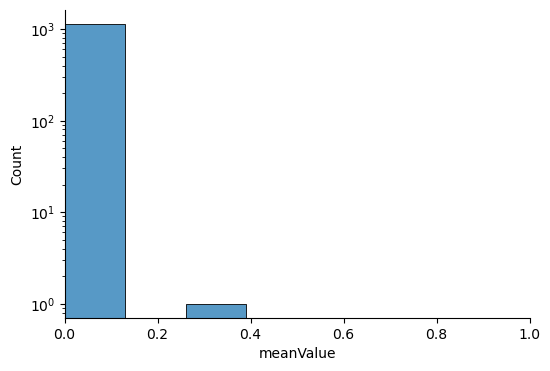

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(sp_avg['meanValue'], bins=50)
ax.set_yscale('log')
ax.set_xlim(0, 1)
sns.despine()

In [11]:
sp_avg.sort_values('meanValue')

,Genome_Pos,species,genomeLen,meanValue,log2mean,max,median
426,5643780005,yHMPu5000034953,9387597.0,0.000000,0.000000,0,0
419,5538364336,yHMPu5000034941,9354271.0,0.000000,0.000000,0,0
27,310752418,komagataella_phaffi,9462757.0,0.000004,0.000000,2,0
26,301154883,komagataella_pastoris,9597535.0,0.000004,0.000000,2,0
24,279300319,kluyveromyces_lactis,10689156.0,0.000025,0.000000,4,0
...,...,...,...,...,...,...,...
43,538182997,saccharomyces_jurei,11938758.0,0.060423,2.411146,258,0
965,12598974090,yHMPu5000038370,11734058.0,0.113310,3.318242,431,0
543,7131121642,yHMPu5000035273,13705311.0,0.116483,3.358088,163,0
5,56360855,candida_auris,12498763.0,0.295246,4.699889,8442,0


In [ ]:
python ~/tools/EnhancedSppIDer/scripts/sppIDer.py --out CommStd_out --ref genomes_combined --r1 ~/fiererlab/beer/data/trimmed_reads/CommStd_S36_R1.trimmed.fastq.gz --r2 ~/fiererlab/be

## Parse sppIDer results

In [8]:
results = glob.glob('./../data/sppider/results/*/*_speciesAvgDepth-g.txt')

In [9]:
dfs = []
for r in results:
    dfs.append(pd.read_csv(r, sep='\t').assign(sample=r.split('/')[-2].split('_S')[0]))
plotdf = pd.concat(dfs)

In [10]:
plotdf.head()

,Genome_Pos,species,genomeLen,meanValue,log2mean,max,median,sample
0,wholeGenome,all,1.508688e+10,0.011360,1.0,8442,0,CommStd
1,0,alloascoidea_hylecoeti,2.481570e+07,0.000296,0.0,30,0,CommStd
2,24815695,ashbya_aceri,8.894523e+06,0.009971,0.0,87,0,CommStd
3,33710218,brettanomyces_anomalus,1.288076e+07,0.000201,0.0,30,0,CommStd
4,46590979,candida_apicola,9.769876e+06,0.002485,0.0,62,0,CommStd


In [12]:
# plotdf = plotdf['

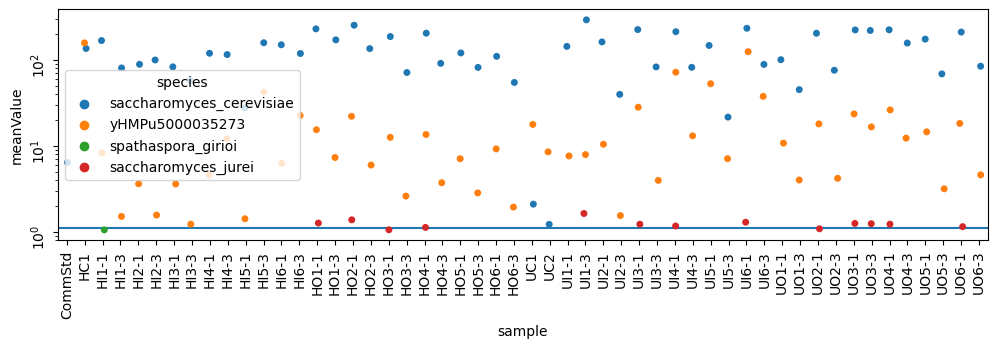

In [13]:
fig, ax = plt.subplots(figsize=(12, 3))
sns.stripplot(data=plotdf[plotdf.meanValue > 1].sort_values('sample'),
              x='sample', y='meanValue', 
              hue='species', palette='tab10')
ax.tick_params(rotation=90)
ax.set_yscale('log')
ax.axhline(1.1)

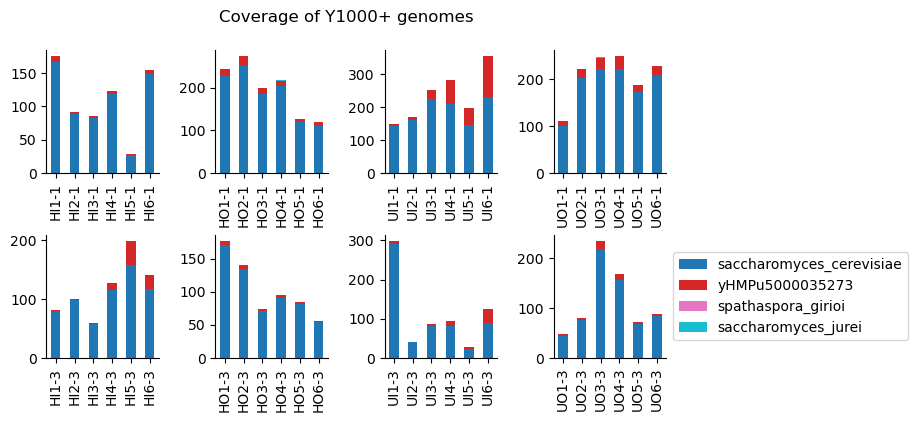

In [24]:
genomes = plotdf[plotdf['meanValue'] > 1]['species'].unique()
fig = plt.figure(figsize=(8,4))
legend=False
for i, timepoint in enumerate([1, 3]):
    for j, (hops, o) in enumerate(itertools.product(['H', 'U'], ['I', 'O'])):
        # print()
        ax = fig.add_subplot(2, 4, (j+1)+(4 * i))
        
        subset = plotdf[plotdf['sample'].str.contains(f'{hops}{o}') & \
                plotdf['sample'].str.contains(f'-{timepoint}') & \
                (plotdf['meanValue'] >= 1)]

        subset_plot = subset.set_index(['sample', 'species'])['meanValue'].unstack().reindex(columns=genomes).fillna(0)
        

        subset_plot.plot(kind='bar', stacked=True, ax=ax,
                         colormap='tab10', legend=legend
                    )
        
        lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        if (j+1)+(4 * i) != 8:
            ax.get_legend().remove()
        ax.set_xlabel(' ')
        sns.despine()
        
fig.subplots_adjust(hspace=0.5, wspace=0.5)
fig.suptitle('Coverage of Y1000+ genomes')
plt.savefig('./../data/figures/sppider_y1000.svg', bbox_inches='tight',
           bbox_extra_artists=(lgd, ))

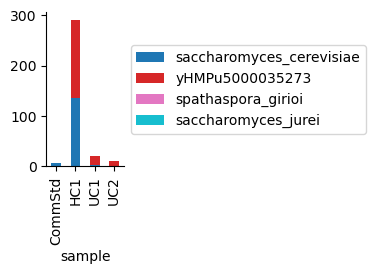

In [23]:
fig, ax = plt.subplots(figsize=(1,2))
subset = plotdf[plotdf['sample'].str.contains(f'C') & \
        (plotdf['meanValue'] >= 1)]

subset_plot = subset.set_index(['sample', 'species'])['meanValue'].unstack().reindex(columns=genomes).fillna(0)

subset_plot.plot(kind='bar', stacked=True, ax=ax,
                 colormap='tab10', legend=True
            )

lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

plt.savefig('./../data/figures/sppider_y1000_controls.svg', bbox_inches='tight',
           bbox_extra_artists=(lgd, ))

In [92]:
md[md['Y1000+_ID'].isin(genomes)]

,assembly_fullID_updated,Y1000+_ID,NEW_Tip_ID,Order,Species,Strain_Sequenced,NRRL,CBS,Other,CTH,...,Missing,Type strain,Type Species,Y1000+ Project,Genome_Acc,Reads_Acc,Citation Number Reference,Reference,Citation number for Related Pub,Related_Prior_Pub
24,yHMPu5000035273_wickerhamomyces_anomalus_18060...,yHMPu5000035273,Wickerhamomyces_anomalus,Phaffomycetales,Wickerhamomyces anomalus,NRRL Y-366,NRRL Y-366,CBS 5759,NaN,NaN,...,0.011699,Yes,No,Yes,JAJMFG000000000,SRR16974551,NaN,New Y1000+,149,"Haase MAB, et al. Repeated horizontal gene tra..."
181,saccharomyces_cerevisiae,saccharomyces_cerevisiae,Saccharomyces_cerevisiae,Saccharomycetales,Saccharomyces cerevisiae,S288C,NaN,CBS 8803,NaN,NaN,...,0.003276,Not Type,Yes,No,SGD,NaN,147.0,"Goffeau A, et al. Life with 6000 genes. Scienc...",,NaN
221,spathaspora_girioi,spathaspora_girioi,Spathaspora_girioi,Serinales,Spathaspora girioi,UFMG-CM-Y302,NaN,CBS 13476,UFMG-CM-Y302,NaN,...,0.005147,Yes,No,Yes,GCA_001657455.1,NaN,167.0,"Lopes MR, et al. Genomic analysis and D-xylose...",,NaN
229,saccharomyces_jurei,saccharomyces_jurei,Saccharomyces_jurei,Saccharomycetales,Saccharomyces jurei,CBS 14759T,NaN,CBS 14759,NCYC 3947,NaN,...,0.004212,Yes,No,No,GCA_900290405.1,NaN,176.0,"Naseeb S, et al. Saccharomyces jurei sp. nov.,...",,NaN


## plot metadata from S. cerevisiae sub-analysis

In [27]:
# load yeast dataset metadata
md = pd.read_csv('./../data/gatk_yeast/yeast_files/Table_S1_G3-2024-405400.txt', skiprows=2, sep='\t')

In [37]:
md[md['SuperClade'].eq('S2. Beer')].groupby(['Clade', 'EcoOrigin', 'GeographicOrigin']).count().sort_values('StandardizedName', ascending=False)

StandardizedName  \
Clade               EcoOrigin                 GeographicOrigin                               
19. UK Beer         Beer                      United Kingdom: England                   16   
18. Belgium Beer 2  Beer                      Belgium                                   16   
19. UK Beer         Beer                      USA                                       10   
                    active dried yeast packet Australia                                  7   
21. Mixed Origins 2 clinical                  Italy                                      6   
...                                                                                    ...   
20. Mixed Origins 1 Active dry yeast          China:Mingguang, Anhui                     1   
                                              China:Daqing, Heilongjiang                 1   
                                              China:Danbao, Guangdong                    1   
                    AB Mauri baking #2        France                                     1   
21. Mixed Origins 2 vaginal fluid             Greece: Thessaloniki                       1   

                                                                          StrainName  \
Clade               EcoOrigin                 GeographicOrigin                         
19. UK Beer         Beer                      United Kingdom: England             16   
18. Belgium Beer 2  Beer                      Belgium                             16   
19. UK Beer         Beer                      USA                                 10   
                    active dried yeast packet Australia                            7   
21. Mixed Origins 2 clinical                  Italy                                6   
...                                                                              ...   
20. Mixed Origins 1 Active dry yeast          China:Mingguang, Anhui               1   
                                              China:Daqing, Heilongjiang           1   
                                              China:Danbao, Guangdong              1   
                    AB Mauri baking #2        France                               1   
21. Mixed Origins 2 vaginal fluid             Greece: Thessaloniki                 1   

                                                                          Paper  \
Clade               EcoOrigin                 GeographicOrigin                    
19. UK Beer         Beer                      United Kingdom: England        16   
18. Belgium Beer 2  Beer                      Belgium                        16   
19. UK Beer         Beer                      USA                            10   
                    active dried yeast packet Australia                       7   
21. Mixed Origins 2 clinical                  Italy                           6   
...                                                                         ...   
20. Mixed Origins 1 Active dry yeast          China:Mingguang, Anhui          1   
                                              China:Daqing, Heilongjiang      1   
                                              China:Danbao, Guangdong         1   
                    AB Mauri baking #2        France                          1   
21. Mixed Origins 2 vaginal fluid             Greece: Thessaloniki            1   

                                                                          SRA  \
Clade               EcoOrigin                 GeographicOrigin                  
19. UK Beer         Beer                      United Kingdom: England      16   
18. Belgium Beer 2  Beer                      Belgium                      16   
19. UK Beer         Beer                      USA                          10   
                    active dried yeast packet Australia                     7   
21. Mixed Origins 2 clinical                  Italy                         6   
...                                                        

In [32]:
md['SuperClade'].unique()

array(['S1. Wine', nan, 'S2. Beer', 'S3. Asian Fermentation', 'S4. Wild'],
      dtype=object)

In [28]:
name2superclade = md.set_index('StandardizedName')['SuperClade']
name2superclade = pd.concat([name2superclade, pd.Series(index=beer_ids, data='mybeer')])

name2clade = md.set_index('StandardizedName')['Clade']

name2clade = pd.concat([name2clade, pd.Series(index=beer_ids, data='mybeer')]).fillna('unassigned')

name2clade

NameError: name 'beer_ids' is not defined